# AllSides Same-Event Corpus: Descriptive Statistics

This notebook examines the structure and characteristics of the AllSides same-event corpus before model prediction and comparative analysis.

## 1. Import and load dataframe

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/allsides_same_event.csv")

df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

df.head()

Rows: 223
Columns: 21


,title,topic,date,summary,tags,left_outlet_name,left_outlet_bias,center_outlet_name,center_outlet_bias,right_outlet_name,...,allsides_url,url_right,title_right,text_right,url_left,title_left,text_left,url_center,title_center,text_center
0,Trump to Deploy National Guard to 'Stop Violen...,Defense and Security,2025-08-11,Updated 8/11/25 1:28pm ET President Donald Tru...,Defense And Security | Washington DC | Crime |...,New York Times (News),Lean Left,The Hill,Center,New York Post (News),...,https://www.allsides.com/story/defense-and-sec...,https://nypost.com/2025/08/11/us-news/us-milit...,US military preparing to surge National Guard ...,The US military is preparing to activate hundr...,https://www.nytimes.com/2025/08/10/us/politics...,Trump Administration to Put F.B.I. Agents on N...,The Trump administration plans to temporarily ...,https://thehill.com/homenews/state-watch/54457...,Donald Trump deploys FBI for DC night patrols ...,The Trump administration will send the FBI on ...
1,Judge Denies DOJ's Request to Unseal Ghislaine...,Criminal Justice,2025-08-11,A US district judge denied the Trump administr...,Criminal Justice | Courts | Donald Trump | Ghi...,CNN Digital,Lean Left,The Hill,Center,New York Post (News),...,https://www.allsides.com/story/criminal-justic...,https://nypost.com/2025/08/11/us-news/manhatta...,Manhattan judge denies Trump admin bid to unse...,A Manhattan federal judge on Monday denied the...,https://www.cnn.com/2025/08/11/politics/maxwel...,Federal judge rejects Trump DOJ’s bid to unsea...,Facebook Tweet Email Link A federal judge has ...,https://thehill.com/regulation/court-battles/5...,Judge refuses request to unseal Ghislaine Maxw...,A federal judge on Monday refused the Justice ...
2,Atlanta Officer Killed After Gunman Opens Fire...,Gun Control and Gun Rights,2025-08-09,"A DeKalb County, Georgia, police officer was k...",CDC | Atlanta | Gun Violence,ABC News (Online),Lean Left,BBC News,Center,New York Post (News),...,https://www.allsides.com/story/gun-control-and...,https://nypost.com/2025/08/08/us-news/active-s...,Officer killed in shooting outside CDC HQ in A...,A cop was killed when an unhinged masked gunma...,https://abcnews.go.com/US/active-shooter-repor...,"Officer killed, suspect identified in shooting...",A police officer was killed when a gunman open...,https://bbc.com/news/articles/cp3ekez0k2xo,Gunman who attacked CDC may have had anti-Covi...,Investigators say that the man who opened fire...
3,550 Former Israeli Officials Call to End Gaza ...,Middle East,2025-08-07,Over 500 former Israeli officials signed an op...,Middle East | Israel | Gaza | Palestine | Benj...,CBC News,Lean Left,BBC News,Center,New York Post (News),...,https://www.allsides.com/story/middle-east-550...,https://nypost.com/2025/08/06/world-news/israe...,Israeli military chief opposes Netanyahu's pla...,The Israel Defense Forces’ top commander is pu...,https://www.cbc.ca/radio/asithappens/israeli-w...,"'I am ashamed of what we are doing in Gaza,' s...",As It Happens 8:46 'I ashamed of what we are d...,https://www.bbc.com/news/articles/crkznje8nz8o,Hundreds of Israeli ex-officials appeal to Tru...,Hundreds of Israeli ex-officials appeal to Tru...
4,"HHS Halts Federal Funding for mRNA Vaccines, P...",Public Health,2025-08-06,The Department of Health and Human Services (H...,Public Health | Vaccines | Health | HHS | Depa...,CBS News (Online),Lean Left,The Hill,Center,Washington Examiner,...,https://www.allsides.com/story/public-health-h...,https://www.washingtonexaminer.com/policy/heal...,HHS cancels development of mRNA vaccines for f...,The 22 affected projects are worth nearly $500...,https://www.cbsnews.com/news/rfk-jr-halts-500-...,RFK Jr. halts $500 million for mRNA vaccine re...,The federal government is calling off around $...,https://thehill.com/policy/healthcare/5437642-...,HHS ends millions in mRNA vaccine development ...,The Department of Health and Human Services (H...


## 2. Inspecting columns

In [2]:
df.columns.tolist()

['title',
 'topic',
 'date',
 'summary',
 'tags',
 'left_outlet_name',
 'left_outlet_bias',
 'center_outlet_name',
 'center_outlet_bias',
 'right_outlet_name',
 'right_outlet_bias',
 'allsides_url',
 'url_right',
 'title_right',
 'text_right',
 'url_left',
 'title_left',
 'text_left',
 'url_center',
 'title_center',
 'text_center']

## 3. Check for missing values

In [3]:
missing_values = df.isna().sum()

missing_values[missing_values > 0]

summary    1
dtype: int64

## 4. Check on orientation counts

In [4]:
print("Left bias values:")
print(df["left_outlet_bias"].value_counts())

print("\nCenter bias values:")
print(df["center_outlet_bias"].value_counts())

print("\nRight bias values:")
print(df["right_outlet_bias"].value_counts())

Left bias values:
left_outlet_bias
Lean Left    162
Left          61
Name: count, dtype: int64

Center bias values:
center_outlet_bias
Center    223
Name: count, dtype: int64

Right bias values:
right_outlet_bias
Lean Right    128
Right          95
Name: count, dtype: int64


In [5]:
print(f"Unique Left outlets: {df['left_outlet_name'].nunique()}")
print(f"Unique Center outlets: {df['center_outlet_name'].nunique()}")
print(f"Unique Right outlets: {df['right_outlet_name'].nunique()}")

Unique Left outlets: 37
Unique Center outlets: 49
Unique Right outlets: 33


## 5. Outlet distribution

In [6]:
print("Most frequent Left outlets:")
print(df["left_outlet_name"].value_counts().head(10))

print("\nMost frequent Center outlets:")
print(df["center_outlet_name"].value_counts().head(10))

print("\nMost frequent Right outlets:")
print(df["right_outlet_name"].value_counts().head(10))

Most frequent Left outlets:
left_outlet_name
CNN (Online News)        38
Associated Press         29
New York Times (News)    19
CNN Business             16
NBC News (Online)        13
The Guardian             12
USA TODAY                10
CBS News (Online)         8
CNN Digital               8
ABC News (Online)         7
Name: count, dtype: int64

Most frequent Center outlets:
center_outlet_name
Newsweek                     48
BBC News                     47
CNBC                         33
Forbes                       25
Christian Science Monitor     4
The Times of Israel           4
Euronews                      3
Roll Call                     3
The Hill                      3
Detroit News                  3
Name: count, dtype: int64

Most frequent Right outlets:
right_outlet_name
Fox News (Online News)     43
Washington Examiner        41
New York Post (News)       37
Fox Business               27
Fox News Digital           13
Breitbart News              9
New York Post (Opinion)  

## 6. Topic distribution

In [7]:
print(f"Unique topics: {df['topic'].nunique()}")

df["topic"].value_counts()

Unique topics: 47


topic
World                              25
Economy and Jobs                   19
Politics                           13
Donald Trump                       12
Middle East                        11
Defense and Security               11
Immigration                         8
Violence in America                 7
2022 Elections                      7
Criminal Justice                    7
Business                            7
2024 Presidential Election          7
Banking and Finance                 6
Joe Biden                           6
Environment                         6
Media Industry                      5
Justice                             5
Technology                          4
Education                           4
Public Health                       4
Russia                              4
Elections                           4
Energy                              3
China                               3
Race and Racism                     3
Supreme Court                       3
Facts 

## 7. Checking time frame

In [8]:
df["date"] = pd.to_datetime(df["date"])

print(f"Earliest date: {df['date'].min().date()}")
print(f"Latest date: {df['date'].max().date()}")

Earliest date: 2015-09-22
Latest date: 2025-08-11


In [9]:
df["year"] = df["date"].dt.year

df["year"].value_counts().sort_index()

year
2015     1
2022    79
2023    60
2024    71
2025    12
Name: count, dtype: int64

## 8. Average word count

In [10]:
df["left_word_count"] = df["text_left"].str.split().str.len()
df["center_word_count"] = df["text_center"].str.split().str.len()
df["right_word_count"] = df["text_right"].str.split().str.len()

df[
    ["left_word_count", "center_word_count", "right_word_count"]
].describe().round(2)

,left_word_count,center_word_count,right_word_count
count,223.00,223.00,223.00
mean,814.12,804.77,704.66
std,478.50,573.18,619.44
min,65.00,68.00,71.00
25%,439.50,483.00,427.00
50%,787.00,674.00,604.00
75%,1025.50,977.50,789.00
max,3126.00,4955.00,7157.00


In [11]:
for side in ["left", "center", "right"]:
    word_count_col = f"{side}_word_count"

    print(f"{side.capitalize()}:")
    print(f"Under 100 words: {(df[word_count_col] < 100).sum()}")
    print(f"Over 3,000 words: {(df[word_count_col] > 3000).sum()}")
    print()

Left:
Under 100 words: 2
Over 3,000 words: 1

Center:
Under 100 words: 3
Over 3,000 words: 3

Right:
Under 100 words: 6
Over 3,000 words: 3



## 9. Checking extreme articles

In [12]:
extreme_articles = []

for side in ["left", "center", "right"]:
    word_count_col = f"{side}_word_count"

    extreme = df[
        (df[word_count_col] < 100)
        | (df[word_count_col] > 3000)
    ]

    for _, row in extreme.iterrows():
        extreme_articles.append(
            {
                "side": side,
                "outlet": row[f"{side}_outlet_name"],
                "article_title": row[f"title_{side}"],
                "word_count": row[word_count_col],
                "text_preview": row[f"text_{side}"][:1000],
            }
        )

extreme_articles_df = pd.DataFrame(extreme_articles)

extreme_articles_df

,side,outlet,article_title,word_count,text_preview
0,left,Bloomberg,FDA Approves First Plan to Import Cheaper Drug...,65,The Biden administration will allow Florida to...
1,left,Associated Press,Hunter Biden found guilty on felony gun charges,67,"Today’s live coverage has ended, but there’s p..."
2,left,Vox,Ron DeSantis’s plan to strip First Amendment r...,3126,Florida’s Republican Gov. Ron DeSantis wants t...
3,center,Forbes,Trump Says He Would 'Look At The Facts' About ...,3404,"May 30, 2025 President Donald Trump said in re..."
4,center,The Jerusalem Post,Antony Blinken announces more than $400 m. in ...,69,Blinken announces more than $400 million in hu...
5,center,The Jerusalem Post,Gazan journalist accused of working for Al Jaz...,71,Did Gazan who held Israeli hostages work for A...
6,center,The Jerusalem Post,US Air Force soldier sets himself on fire outs...,68,US Air Force soldier sets himself on fire outs...
7,center,BBC News,Obituary: Queen Elizabeth II,3080,Obituary: Queen Elizabeth II Chris Levine/Rob ...
8,center,Forbes,AI Battle Royale Erupts With Google Bard Versu...,4955,AI battle brewing that entails the mighty gian...
9,right,The Epoch Times,Four Americans Convicted in Russian Influence ...,85,"Omali Yeshitela, founder of the African People..."


In [13]:
# short articles
for side in ["left", "center", "right"]:
    short_articles = df[df[f"{side}_word_count"] < 100]

    for _, row in short_articles.iterrows():
        print("\n")
        print(f"Side: {side}")
        print(f"Outlet: {row[f'{side}_outlet_name']}")
        print(f"Title: {row[f'title_{side}']}")
        print(f"Word count: {row[f'{side}_word_count']}")
        print()
        print(row[f"text_{side}"])
        print()



Side: left
Outlet: Bloomberg
Title: FDA Approves First Plan to Import Cheaper Drugs From Canada
Word count: 65

The Biden administration will allow Florida to import cheaper prescription drugs from Canada, giving the green light to a plan that could spur other states to follow suit. The Food and Drug Administration made the decision on Florida’s plan Friday, saying that the state’s health department must likewise provide quarterly reports to the agency, including information on cost savings and potential safety and quality issues.



Side: left
Outlet: Associated Press
Title: Hunter Biden found guilty on felony gun charges
Word count: 67

Today’s live coverage has ended, but there’s plenty to catch up on. See how the news unfolded below and find more coverage at apnews.com. Hunter Biden has been convicted of all three felony charges related to the purchase of a revolver in 2018 when , prosecutors argued, the president’s son lied on a mandatory gun-purchase form by saying he was not i

In [14]:
df.loc[
    (df["right_outlet_name"] == "Fox News Digital")
    & (df["right_word_count"] == 71),
    ["title", "topic", "title_right", "url_right"]
]

,title,topic,title_right,url_right
85,ICE Arrests 8 Suspects With Ties to ISIS,Defense and Security,ICE arrests eight men suspected to have ties t...,https://foxnews.com/video/6354860368112


In [15]:
for side in ["left", "center", "right"]:
    video_rows = df[
        df[f"url_{side}"].str.contains("/video/", case=False, na=False)
    ]

    print(f"{side.capitalize()} video URLs: {len(video_rows)}")
    print(video_rows[["title", f"title_{side}", f"url_{side}"]])
    print()

Left video URLs: 1
                                        title  \
93  Gas Prices Are Falling. Will it Continue?   

                                           title_left  \
93  Gas prices could pick up in summer from refine...   

                                             url_left  
93  https://finance.yahoo.com/video/gas-prices-cou...  

Center video URLs: 0
Empty DataFrame
Columns: [title, title_center, url_center]
Index: []

Right video URLs: 1
                                       title  \
85  ICE Arrests 8 Suspects With Ties to ISIS   

                                          title_right  \
85  ICE arrests eight men suspected to have ties t...   

                                  url_right  
85  https://foxnews.com/video/6354860368112  



In [16]:
row = df.loc[
    df["url_left"].str.contains("/video/", case=False, na=False)
].iloc[0]

print(f"Title: {row['title_left']}")
print(f"Outlet: {row['left_outlet_name']}")
print(f"Word count: {row['left_word_count']}")
print()
print(row["text_left"])

Title: Gas prices could pick up in summer from refinery pressures
Outlet: Yahoo News
Word count: 146

CIBC Private Wealth US Senior Energy Trader Rebecca Babin joins Yahoo Finance's Market Domination to talk about the price pressures in the energy market stemming from OPEC's extended production cuts for oil ( CL=F , BZ=F ) and its spillover into gas prices ( RB=F ) ahead of the summer season. "Over the course of the summer, we're going to see a lift in gas prices, probably closer to that kind of $3.65, $3.70 level. Nowhere near the point where it starts to make people change their mind on consumption," Babin states. "But I would expect we see a bottoming here, and throughout the course of the summer we see a little incremental rise as demand picks up..." For more expert insight and the latest market action, click here to watch this full episode of Market Domination. This post was written by Luke Carberry Mogan .


In [17]:
row = df.loc[
    (df["right_outlet_name"] == "Fox News (Online News)")
    & (df["right_word_count"] == 7157)
].iloc[0]

print(f"Title: {row['title_right']}")
print(f"Word count: {row['right_word_count']}")
print()

print("START OF TEXT:")
print(row["text_right"][:2000])

print("\n\n")

print("END OF TEXT:")
print(row["text_right"][-2000:])

Title: Queen Elizabeth II's death: King Charles III delivers address at Buckingham Palace in England
Word count: 7157

START OF TEXT:
5 facts about Queen Elizabeth II: From her armed forces service in WWII to her childhood nickname Queen Elizabeth II spent most of her years in the spotlight after ascending to the throne at the age of 25. The monarch, who died on Thursday at the age of 96, had enjoyed relative privacy before becoming a global figure overnight when her father King George VI passed away unexpectedly in 1952. Though the queen was often under the scrutiny of the public eye, there are several lesser-known facts about her long life. Click here to read more fun facts on the late monarch. Fox News' Ashley Hume contributed to this report. Dolly Parton shares tribute for Queen Elizabeth II Dolly Parton is sharing a tribute in honor of Queen Elizabeth II. The country legend took to Twitter on Friday and wrote, "I had the honor of meeting and performing for Queen Elizabeth II on my

In [18]:
df.loc[
    df["right_word_count"] == 7157,
    [
        "title",
        "left_outlet_name",
        "left_word_count",
        "center_outlet_name",
        "center_word_count",
        "right_outlet_name",
        "right_word_count",
    ],
]

,title,left_outlet_name,left_word_count,center_outlet_name,center_word_count,right_outlet_name,right_word_count
148,Queen Elizabeth II Dies at 96,New York Times (News),1843,BBC News,3080,Fox News (Online News),7157


might remove this event because right has scraping noise

In [19]:
df.loc[
    df["right_word_count"] == 71,
    [
        "title",
        "left_outlet_name",
        "left_word_count",
        "center_outlet_name",
        "center_word_count",
        "right_outlet_name",
        "right_word_count",
    ],
]

,title,left_outlet_name,left_word_count,center_outlet_name,center_word_count,right_outlet_name,right_word_count
85,ICE Arrests 8 Suspects With Ties to ISIS,NBC News Digital,340,ABC 6,625,Fox News Digital,71


exclude this event too

In [20]:
# check urls
all_urls = pd.concat(
    [
        df["url_left"],
        df["url_center"],
        df["url_right"],
    ],
    ignore_index=True,
)

print(f"Article slots: {len(all_urls):,}")
print(f"Unique article URLs: {all_urls.nunique():,}")
print(f"Repeated article URLs: {all_urls.duplicated().sum():,}")

Article slots: 669
Unique article URLs: 669
Repeated article URLs: 0


In [21]:
# check if any artcile texts are duplicates 
all_texts = pd.concat(
    [
        df["text_left"],
        df["text_center"],
        df["text_right"],
    ],
    ignore_index=True,
)

print(f"Article texts: {len(all_texts):,}")
print(f"Unique article texts: {all_texts.nunique():,}")
print(f"Repeated article texts: {all_texts.duplicated().sum():,}")

Article texts: 669
Unique article texts: 669
Repeated article texts: 0


In [22]:
print(f"Left total words: {df['left_word_count'].sum():,}")
print(f"Center total words: {df['center_word_count'].sum():,}")
print(f"Right total words: {df['right_word_count'].sum():,}")

print(
    f"Total corpus words: "
    f"{df[['left_word_count', 'center_word_count', 'right_word_count']].sum().sum():,}"
)

Left total words: 181,548
Center total words: 179,464
Right total words: 157,140
Total corpus words: 518,152


In [23]:
long_article_list = []

for side in ["left", "center", "right"]:
    long_articles = df[df[f"{side}_word_count"] > 3000]

    for _, row in long_articles.iterrows():
        long_article_list.append(
            {
                "side": side,
                "outlet": row[f"{side}_outlet_name"],
                "word_count": row[f"{side}_word_count"],
                "title": row[f"title_{side}"],
            }
        )

print(pd.DataFrame(long_article_list).to_string(index=False))

  side                 outlet  word_count                                                                                                           title
  left                    Vox        3126                                              Ron DeSantis’s plan to strip First Amendment rights from the press
center                 Forbes        3404                                                  Trump Says He Would 'Look At The Facts' About Potential Pardon
center               BBC News        3080                                                                                    Obituary: Queen Elizabeth II
center                 Forbes        4955 AI Battle Royale Erupts With Google Bard Versus Microsoft OpenAI ChatGPT, Stoking AI Ethics And AI Law Concerns
 right    Washington Examiner        3355                                       In Egypt and then Israel, Blinken pushes on all fronts for Gaza ceasefire
 right             Daily Mail        3034                                  U

In [24]:
row = df.loc[
    (df["right_outlet_name"] == "Washington Examiner")
    & (df["right_word_count"] == 3355)
].iloc[0]

print(f"Title: {row['title_right']}")
print(f"Word count: {row['right_word_count']}")
print()

print("START:")
print(row["text_right"][:1500])

print("\n\n")

print("END:")
print(row["text_right"][-1500:])

Title: In Egypt and then Israel, Blinken pushes on all fronts for Gaza ceasefire
Word count: 3355

START:
“The Secretary reiterated that the United States and other world leaders will stand behind the comprehensive proposal outlined by President Biden that would lead to an immediate ceasefire in Gaza, the release of all hostages, and a significant and sustained increase in humanitarian assistance for distribution throughout Gaza,” the State Department said in a readout of Blinken’s meeting with Netanyahu. Blinken arrived in Israel after a stop in Cairo for talks with Egyptian President Abdel Fattah el Sissi . “My message to governments throughout the region, to people throughout the region is: If you want a ceasefire, press Hamas to say yes. If you want to alleviate the terrible suffering of Palestinians in Gaza, press Hamas to say yes. If you want to get all the hostages home, press Hamas to say yes. If you want to put Israelis and Palestinians alike on the path to more durable peace 

marked for exclusion as well, scraping noise

In [25]:
row = df.loc[
    (df["center_outlet_name"] == "Forbes")
    & (df["center_word_count"] == 4955)
].iloc[0]

print(f"Title: {row['title_center']}")
print(f"Word count: {row['center_word_count']}")
print()

print("START:")
print(row["text_center"][:1500])

print("\n\n")

print("END:")
print(row["text_center"][-1500:])

Title: AI Battle Royale Erupts With Google Bard Versus Microsoft OpenAI ChatGPT, Stoking AI Ethics And AI Law Concerns
Word count: 4955

START:
AI battle brewing that entails the mighty giant Google with its announced Bard versus giant Microsoft coupled with business partner OpenAI and ChatGPT. getty Get your helmet on and be ready for the fallout from an emerging battle royale in AI. Here’s the deal. In one corner stands Microsoft with their business partner OpenAI and ChatGPT. Leering anxiously in the other corner is Google, which has announced that they will be making available a similar type of AI, based on their long-standing insider AI app known as LaMDA. LaMDA sounds kind of techie, which is a stark contrast to “ChatGPT” (seems kind of light and airy). Google, perhaps realizing that a name embellishment was needed, has opted to put forth its variant of LaMDA and anointed it with a new name “Bard”. I’ll say more about Bard in a moment, hang in there. We are on the cusp of ChatGPT

In [26]:
row = df.loc[
    (df["right_outlet_name"] == "Daily Mail")
    & (df["right_word_count"] == 3034)
].iloc[0]

print(f"Title: {row['title_right']}")
print(f"Word count: {row['right_word_count']}")
print()

print("START:")
print(row["text_right"][:1500])

print("\n\n")

print("END:")
print(row["text_right"][-1500:])

Title: Ukraine war: Zelensky raises flag over re-captured Russian stronghold of Izyum
Word count: 3034

START:
Volodymyr Zelensky has helped raised the Ukrainian flag over the newly-recaptured Russian stronghold of Izyum as he celebrates a stunning counter-attack that routed Putin's forces in the north of the country. The Ukrainian president took part in a minute of silence for fallen soldiers before congratulating those still fighting on their victory. He then raising the flag in triumph over the city - which previously served as the launchpad for the Putin's mission to seize the entire Donbas region. 'Ukraine is taking back its own,' a military spokesman said, as a growing hope of overall victory against Putin's forces begins to spread across the country in the wake of Russia's most-recent battlefield humiliation. The scale of the unfolding military disaster is so great that not even the Kremlin's sock-puppet propagandists are trying to disguise it, instead telling viewers on Monday 

In [27]:
row = df.loc[
    (df["left_outlet_name"] == "Vox")
    & (df["left_word_count"] == 3126)
].iloc[0]

print(f"Title: {row['title_left']}")
print(f"Word count: {row['left_word_count']}")
print()

print("START:")
print(row["text_left"][:1500])

print("\n\n")

print("END:")
print(row["text_left"][-1500:])

Title: Ron DeSantis’s plan to strip First Amendment rights from the press
Word count: 3126

START:
Florida’s Republican Gov. Ron DeSantis wants to eliminate the First Amendment safeguards that prevent lawsuits seeking to strong-arm the press into silence. He’s been very clear about this goal: In February, DeSantis led a roundtable discussion brainstorming ideas to weaken the press’s First Amendment protections . Flanked by a panel dominated by defamation plaintiffs and lawyers, the Orbánesque governor attacked the Supreme Court’s landmark decision in New York Times v. Sullivan (1964) for, in his words, empowering a media that will “find a way to smear you.” Sullivan was a historic decision establishing that the government (and, in many cases, private litigants) may not censor the media, political advocates, and the public at large through defamation suits intended to shut down dissenting voices. The case arose out of a Jim Crow-era official’s attempt to silence civil rights protesters 

In [28]:
row = df.loc[
    (df["center_outlet_name"] == "Forbes")
    & (df["center_word_count"] == 3404)
].iloc[0]

print(f"Title: {row['title_center']}")
print(f"Word count: {row['center_word_count']}")
print()

print("START:")
print(row["text_center"][:1500])

print("\n\n")

print("END:")
print(row["text_center"][-1500:])

Title: Trump Says He Would 'Look At The Facts' About Potential Pardon
Word count: 3404

START:
May 30, 2025 President Donald Trump said in response to a reporter’s question about possibly pardoning Combs that he would “look at the facts,” acknowledging he has not closely followed the trial and stating he hasn’t seen or spoken to Combs in years since he entered politics. May 29, 2025 One of the alleged victims central to the prosecution’s case against Combs took the witness stand under the pseudonym “Mia,” testifying Combs sexually assaulted her on multiple occasions, including at a hotel in New York during his 40th birthday party celebrations and multiple times at his Los Angeles home, while she worked as his personal assistant. May 22, 2025 Rapper Kid Cudi took the witness stand and testified Combs broke into his house after learning Kid Cudi was dating Cassie Ventura in late 2011, and that several weeks later his car was firebombed in his driveway, which he said he believes Combs “ha

In [29]:
row = df.loc[
    (df["center_outlet_name"] == "BBC News")
    & (df["center_word_count"] == 3080)
].iloc[0]

print(f"Title: {row['title_center']}")
print(f"Word count: {row['center_word_count']}")
print()

print("START:")
print(row["text_center"][:1500])

print("\n\n")

print("END:")
print(row["text_center"][-1500:])

Title: Obituary: Queen Elizabeth II
Word count: 3080

START:
Obituary: Queen Elizabeth II Chris Levine/Rob Munday © Jersey Heritage Trust The long reign of Queen Elizabeth II was marked by her strong sense of duty and her determination to dedicate her life to her throne and to her people. She became for many the one constant point in a rapidly changing world as British influence declined, society changed beyond recognition and the role of the monarchy itself came into question. Her success in maintaining the monarchy through such turbulent times was even more remarkable given that, at the time of her birth, no-one could have foreseen that the throne would be her destiny. Elizabeth Alexandra Mary Windsor was born on 21 April 1926, in a house just off Berkeley Square in London, the first child of Albert, Duke of York, second son of George V, and his duchess, the former Lady Elizabeth Bowes-Lyon. Getty Images Baby Elizabeth with her parents at her christening Both Elizabeth and her sister

In [30]:
print(
    df.loc[
        (df["right_outlet_name"] == "Washington Examiner")
        & (df["right_word_count"] == 3355),
        "title",
    ].iloc[0]
)

Blinken Visits Middle East to Push Gaza Ceasefire Plan, Announces New Humanitarian Aid


In [31]:
excluded_events = [
    "Queen Elizabeth II Dies at 96",
    "ICE Arrests 8 Suspects With Ties to ISIS",
    "Blinken Visits Middle East to Push Gaza Ceasefire Plan, Announces New Humanitarian Aid",
]

cleaned_df = df[~df["title"].isin(excluded_events)].reset_index(drop=True)

In [32]:
print(f"Left total words: {cleaned_df['left_word_count'].sum():,}")
print(f"Center total words: {cleaned_df['center_word_count'].sum():,}")
print(f"Right total words: {cleaned_df['right_word_count'].sum():,}")

print(
    f"Total cleaned corpus words: "
    f"{cleaned_df[['left_word_count', 'center_word_count', 'right_word_count']].sum().sum():,}"
)

Left total words: 178,646
Center total words: 175,690
Right total words: 146,557
Total cleaned corpus words: 500,893


In [33]:
cleaned_df[
    ["left_word_count", "center_word_count", "right_word_count"]
].describe().round(2)

,left_word_count,center_word_count,right_word_count
count,220.00,220.00,220.00
mean,812.03,798.59,666.17
std,475.59,553.84,404.31
min,65.00,68.00,78.00
25%,440.25,486.00,432.00
50%,791.50,678.50,603.00
75%,1025.25,976.75,787.25
max,3126.00,4955.00,3034.00


In [34]:
pd.DataFrame(
    {
        "orientation": ["Left", "Center", "Right"],
        "unique_outlets": [
            cleaned_df["left_outlet_name"].nunique(),
            cleaned_df["center_outlet_name"].nunique(),
            cleaned_df["right_outlet_name"].nunique(),
        ],
    }
)

,orientation,unique_outlets
0,Left,37
1,Center,48
2,Right,33


## 10. Plots for thesis

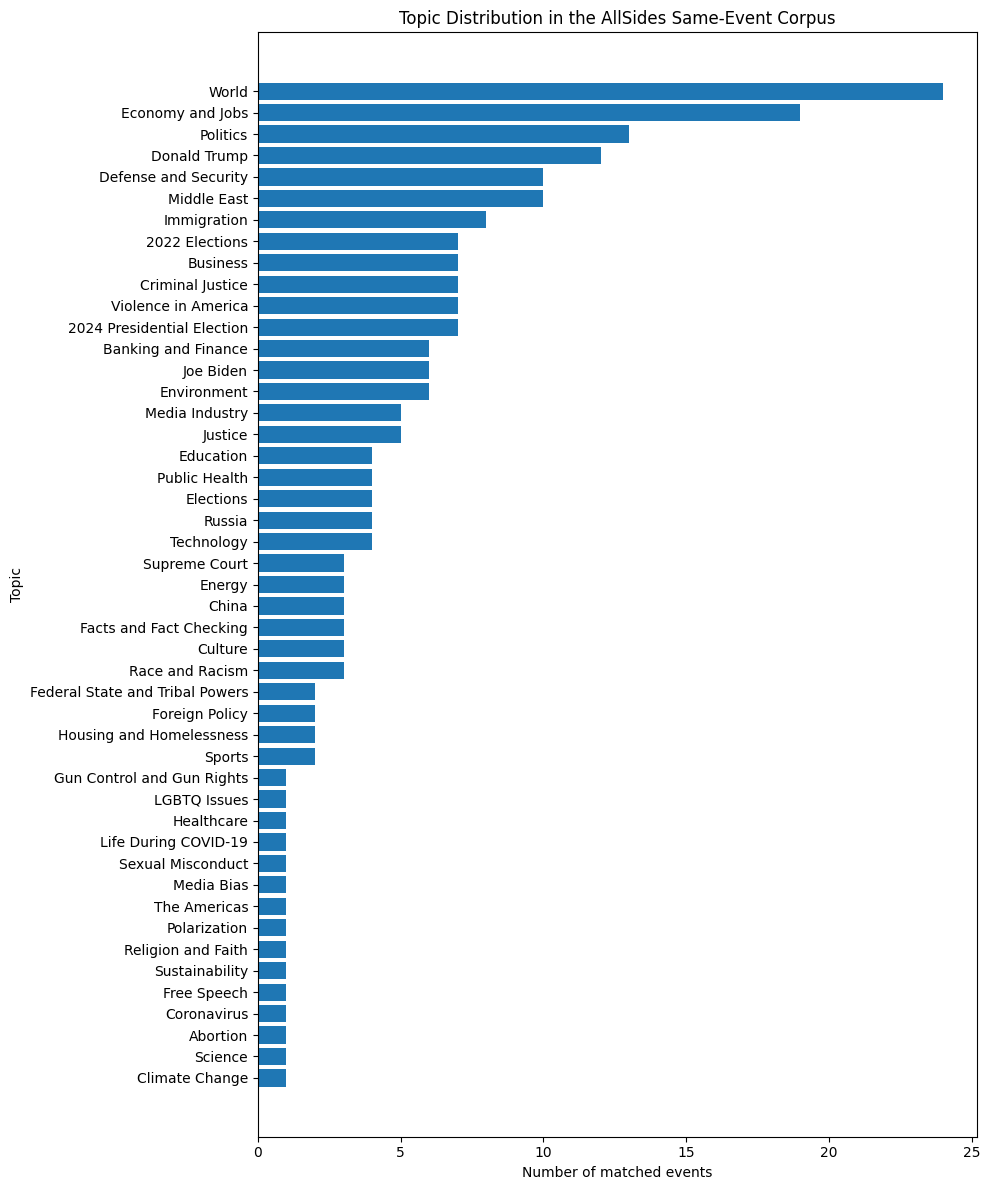

In [41]:
# topic distributiuon
topic_counts = cleaned_df["topic"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 12))

ax.barh(topic_counts.index, topic_counts.values)

ax.set_title("Topic Distribution in the AllSides Same-Event Corpus")
ax.set_xlabel("Number of matched events")
ax.set_ylabel("Topic")

plt.tight_layout()
fig.savefig(
    "../figures/allsides_same_events_topic_distribution.pdf",
    bbox_inches="tight"
)
plt.show()

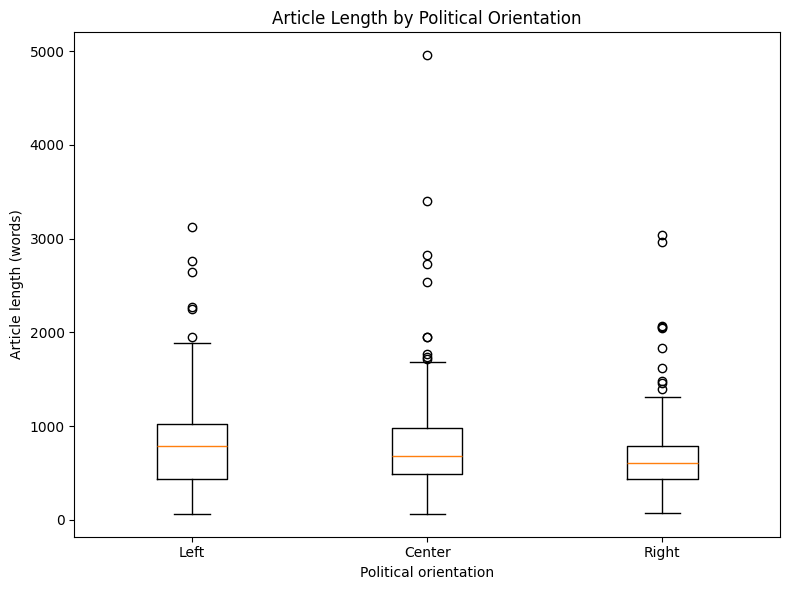

In [37]:
# length of article compared to orientation
fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(
    [
        cleaned_df["left_word_count"],
        cleaned_df["center_word_count"],
        cleaned_df["right_word_count"],
    ],
    tick_labels=["Left", "Center", "Right"],
    showfliers=True,
)

ax.set_title("Article Length by Political Orientation")
ax.set_xlabel("Political orientation")
ax.set_ylabel("Article length (words)")

plt.tight_layout()

plt.savefig(
    "../figures/allsides_same_events_article_length_by_orientation.pdf",
    bbox_inches="tight",
)

plt.show()

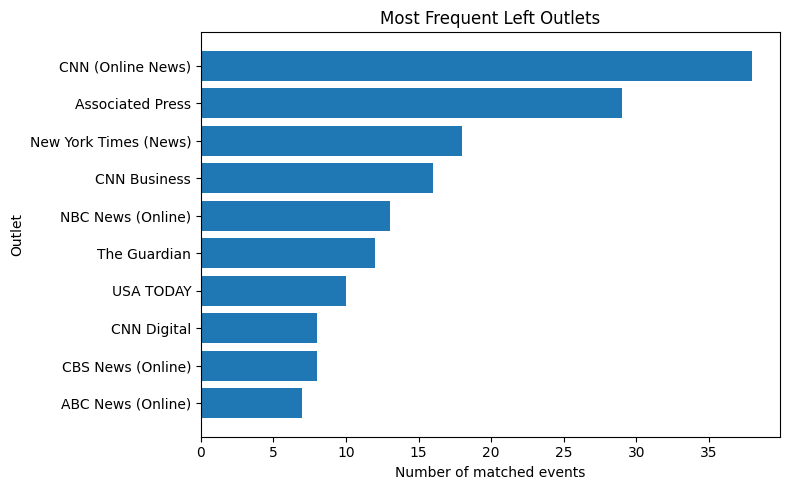

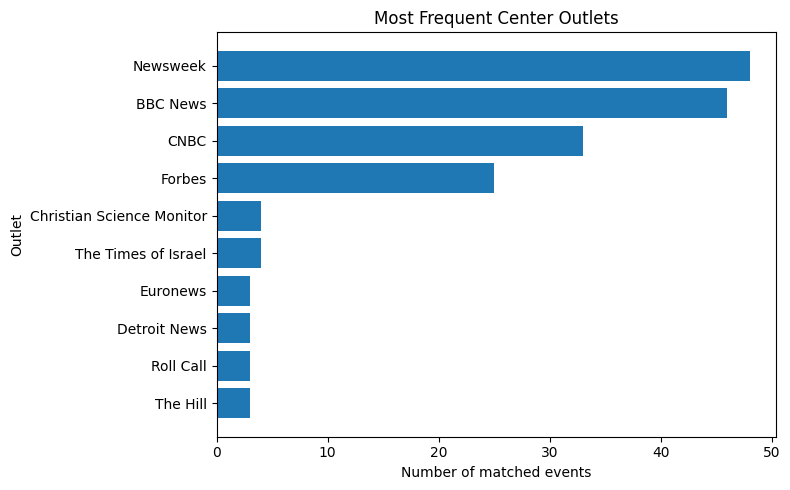

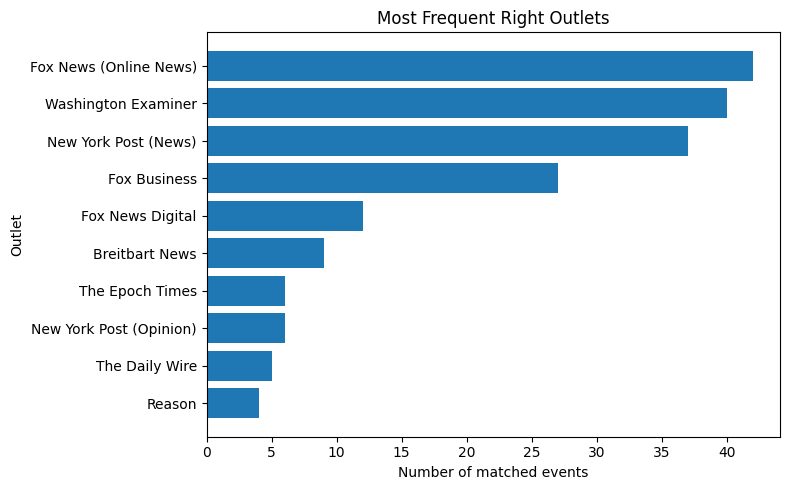

In [38]:
# outlet representation
for side, label in [
    ("left", "Left"),
    ("center", "Center"),
    ("right", "Right"),
]:
    outlet_counts = (
        cleaned_df[f"{side}_outlet_name"]
        .value_counts()
        .head(10)
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.barh(outlet_counts.index, outlet_counts.values)

    ax.set_title(f"Most Frequent {label} Outlets")
    ax.set_xlabel("Number of matched events")
    ax.set_ylabel("Outlet")

    plt.tight_layout()

    plt.savefig(
        f"../figures/allsides_same_events_top_outlets_{side}.pdf",
        bbox_inches="tight",
    )

    plt.show()

In [39]:
cleaned_df.to_csv(
    "../data/allsides_same_events_final.csv",
    index=False,
)

In [40]:
corpus_summary = pd.DataFrame(
    {
        "orientation": ["Left", "Center", "Right"],
        "articles": [len(cleaned_df)] * 3,
        "total_words": [
            cleaned_df["left_word_count"].sum(),
            cleaned_df["center_word_count"].sum(),
            cleaned_df["right_word_count"].sum(),
        ],
        "unique_outlets": [
            cleaned_df["left_outlet_name"].nunique(),
            cleaned_df["center_outlet_name"].nunique(),
            cleaned_df["right_outlet_name"].nunique(),
        ],
        "mean_words": [
            cleaned_df["left_word_count"].mean(),
            cleaned_df["center_word_count"].mean(),
            cleaned_df["right_word_count"].mean(),
        ],
        "median_words": [
            cleaned_df["left_word_count"].median(),
            cleaned_df["center_word_count"].median(),
            cleaned_df["right_word_count"].median(),
        ],
    }
)

corpus_summary.round(2)

,orientation,articles,total_words,unique_outlets,mean_words,median_words
0,Left,220,178646,37,812.03,791.5
1,Center,220,175690,48,798.59,678.5
2,Right,220,146557,33,666.17,603.0
